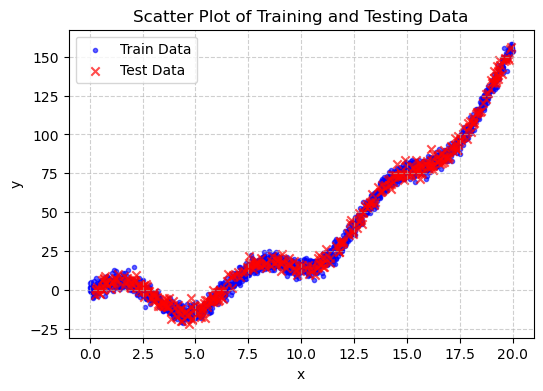

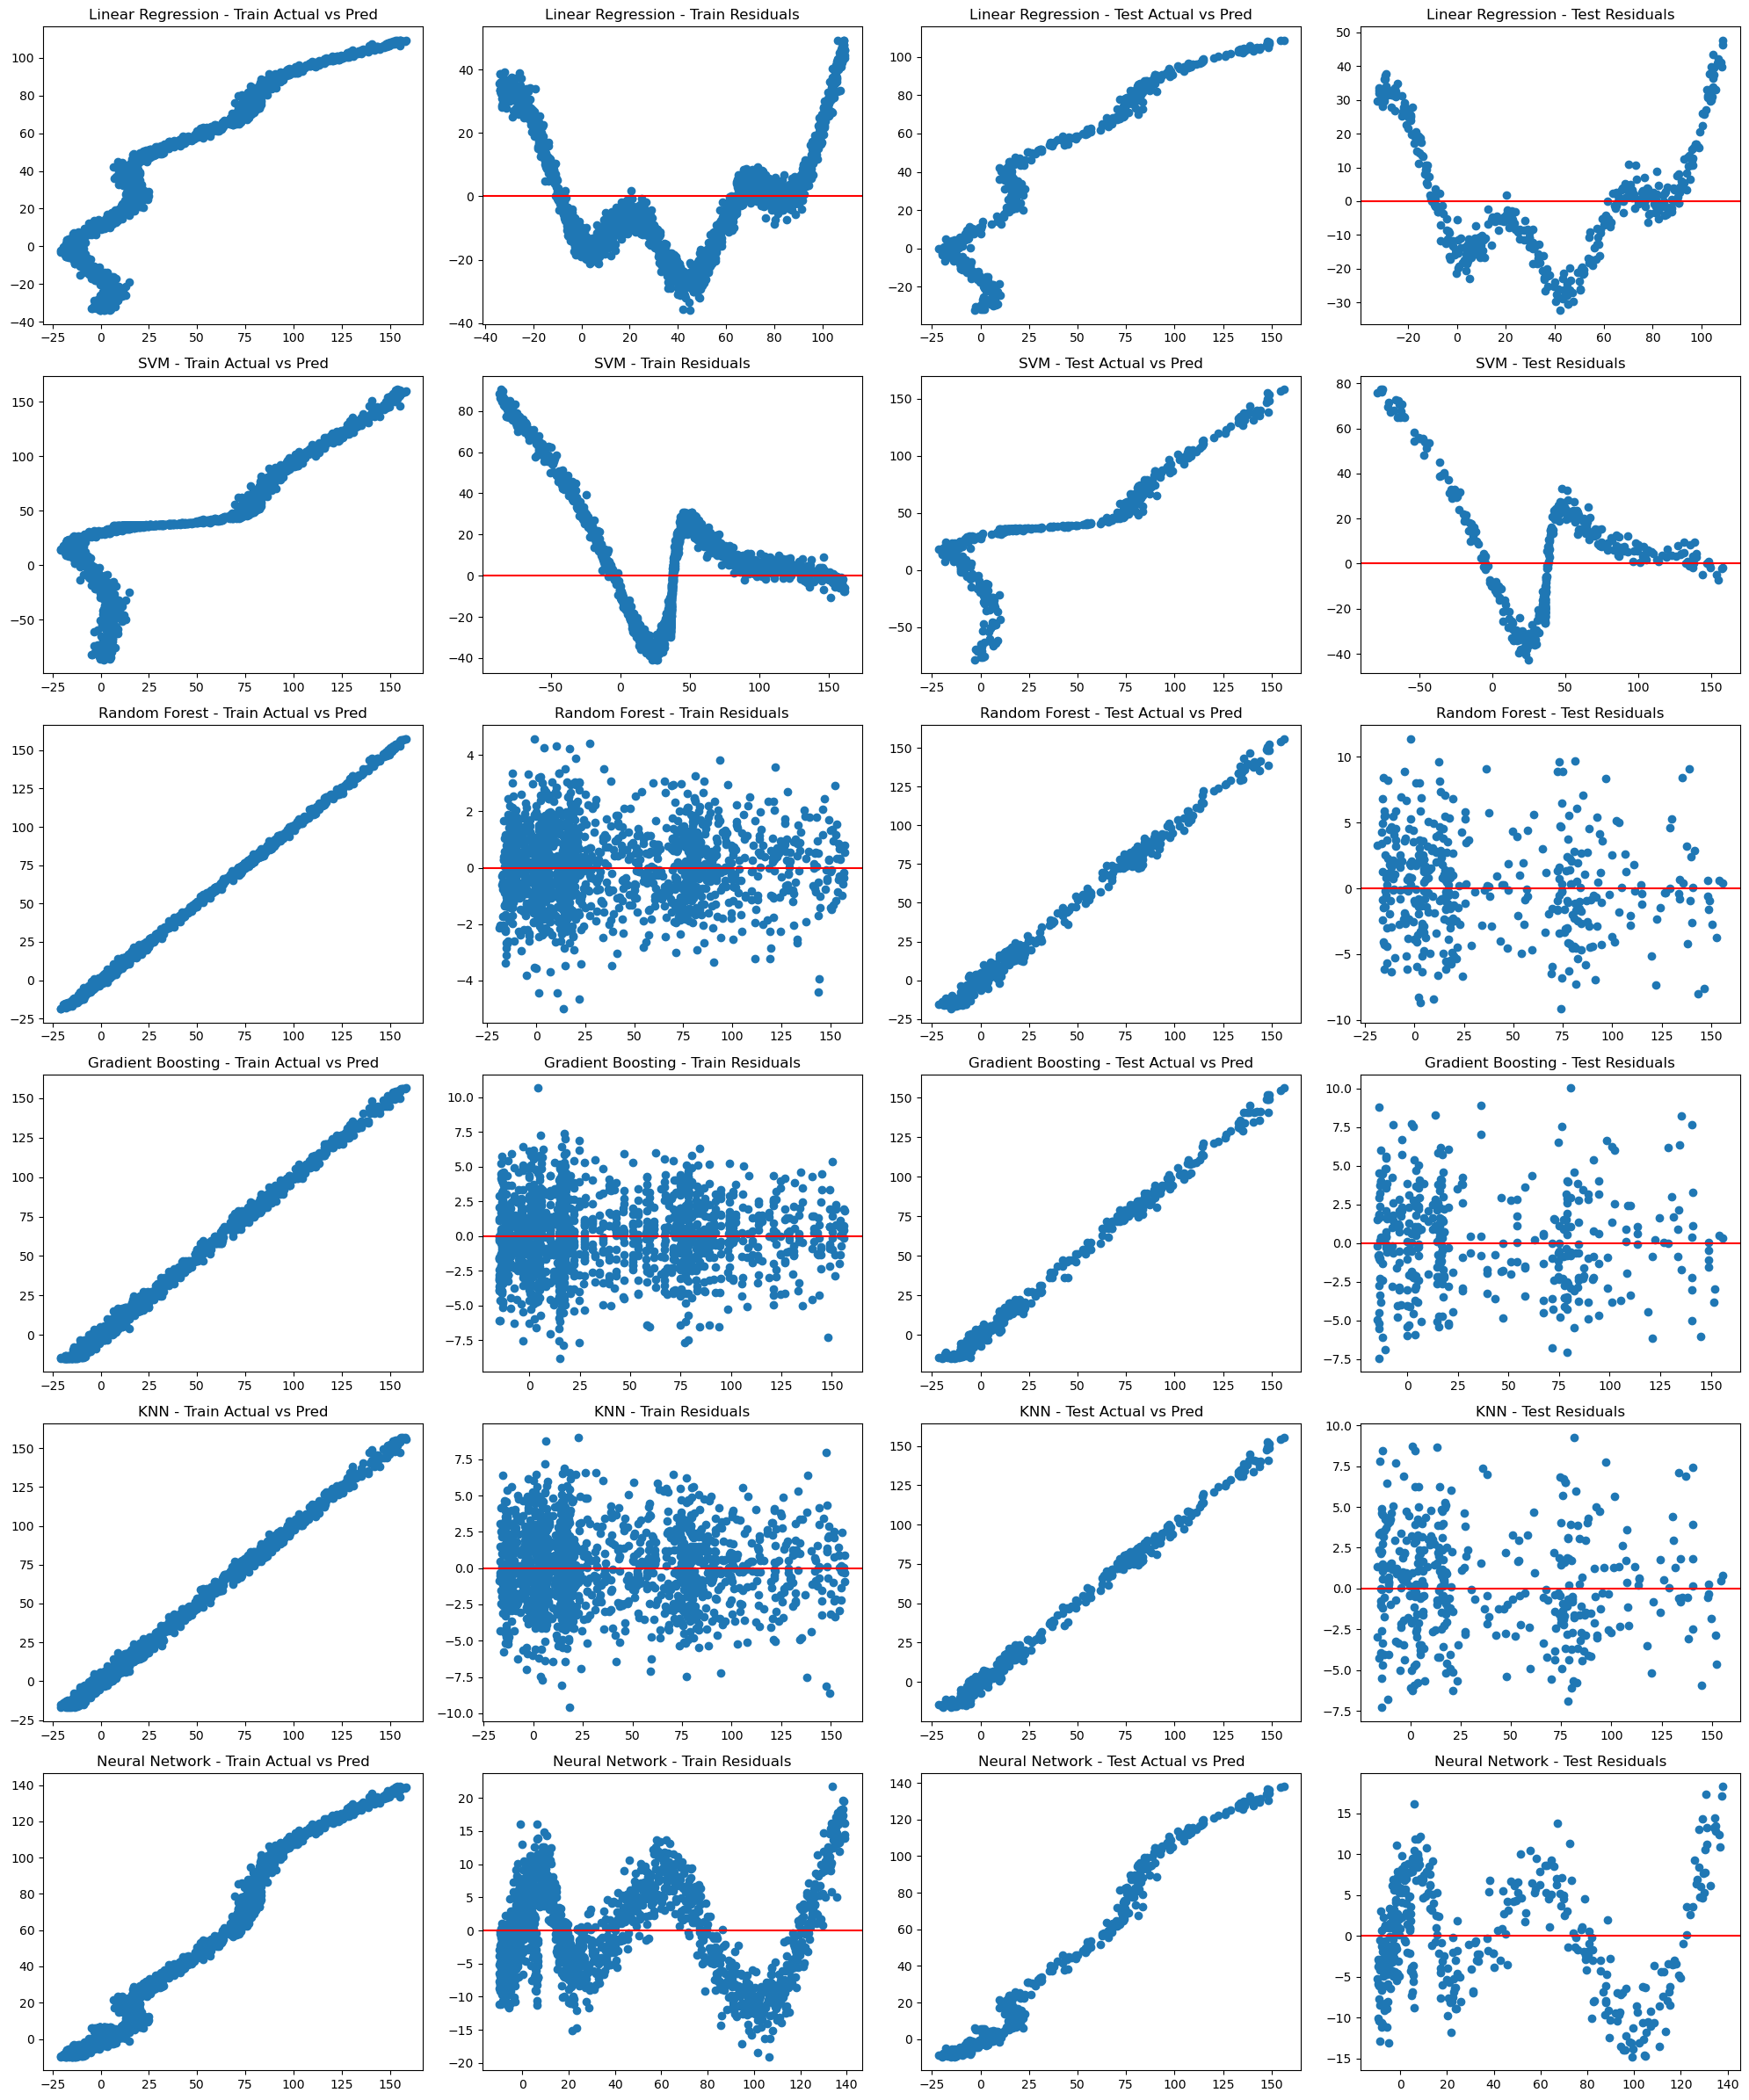

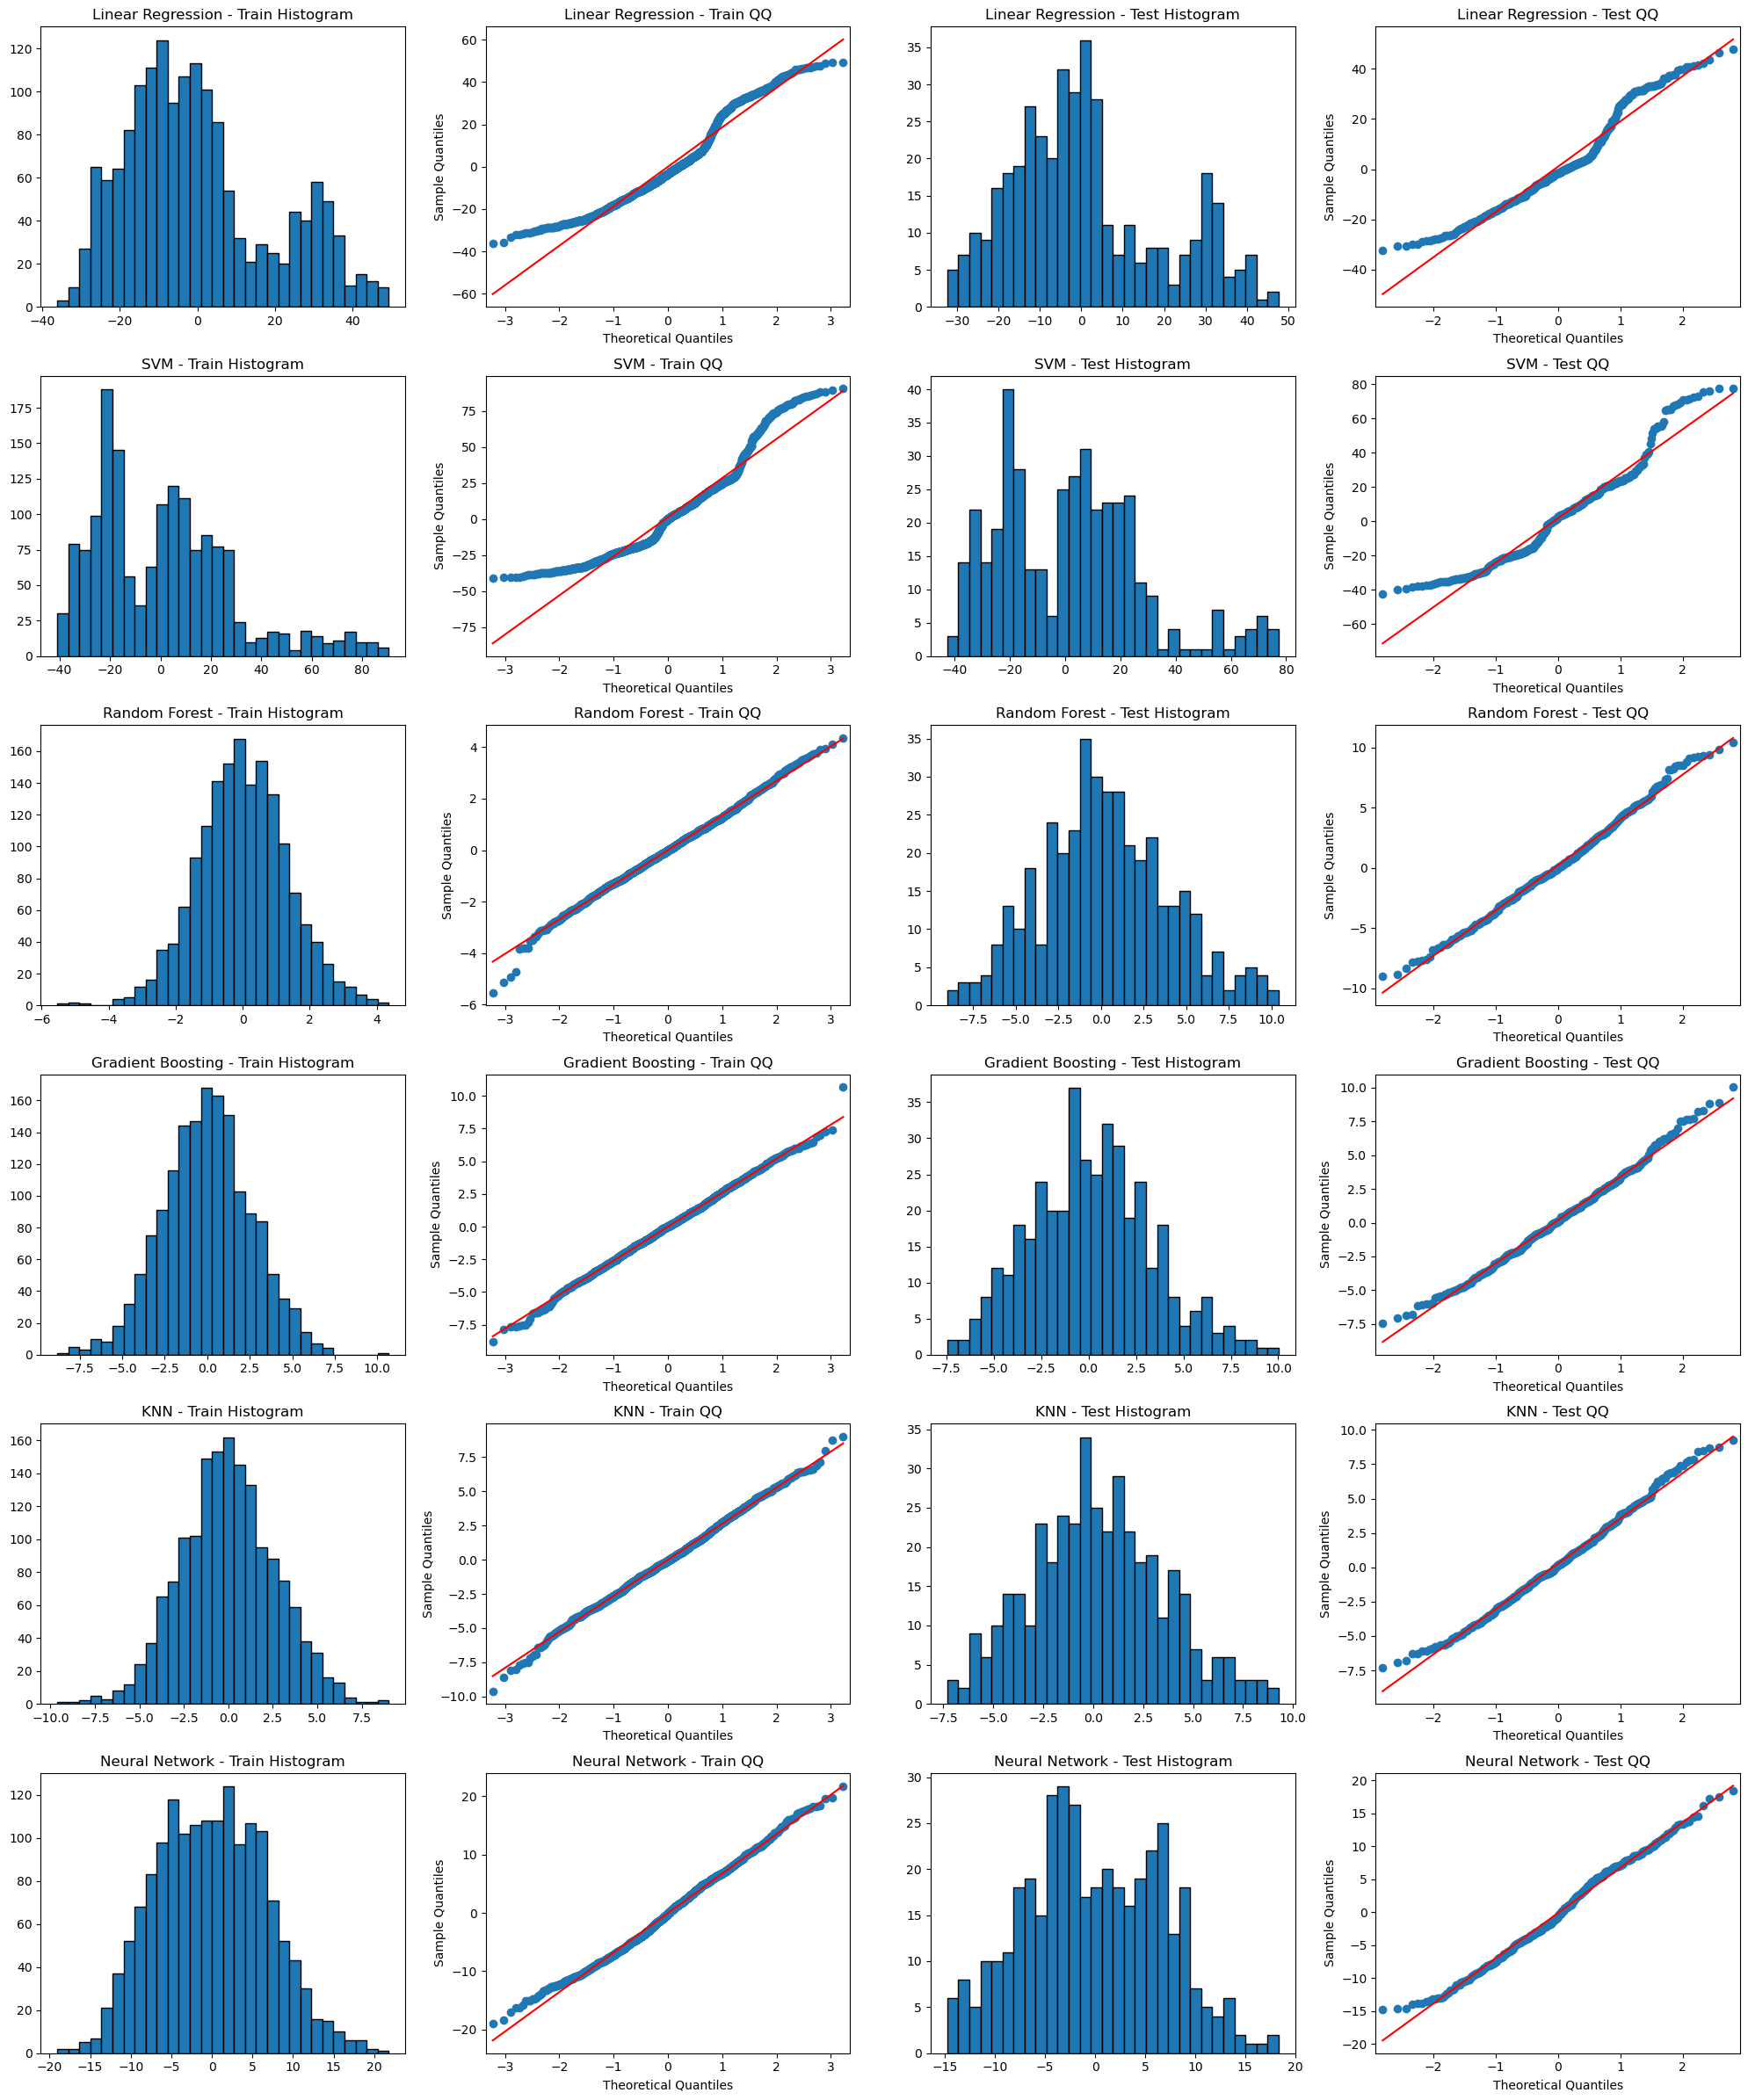


==== TRAIN METRICS ====

                         R2       RMSE  Durbin-Watson  Jarque-Bera  \
Linear Regression  0.829553  18.656644       2.024608   117.827752   
SVM                0.638358  27.175561       1.987561   251.590113   
Random Forest      0.999132   1.331492       2.053460     9.115382   
Gradient Boosting  0.996693   2.598827       2.089983     0.569595   
KNN                0.996598   2.635583       2.092051     0.594478   
Neural Network     0.977496   6.779078       2.042096    16.589599   

                     JB p-value  
Linear Regression  2.594351e-26  
SVM                2.332926e-55  
Random Forest      1.048624e-02  
Gradient Boosting  7.521666e-01  
KNN                7.428664e-01  
Neural Network     2.498126e-04  

==== TEST METRICS ====

                         R2       RMSE  Durbin-Watson  Jarque-Bera  \
Linear Regression  0.850458  18.078457       1.904427    25.441873   
SVM                0.689803  26.037513       1.990964    35.111435   
Random For

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm

# =========================
# Reproducibility
# =========================
np.random.seed(42)

# =========================
# Data Loading
# =========================
file_path = "data/Assignment_8_regression_multiple_methods.xlsx"

train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

# =========================
# Data Preparation
# =========================
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

# For plotting
x_train = train_data['x']
x_test = test_data['x']

# =========================
# Visualization
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train, color='blue', label='Train Data', alpha=0.6, marker='.')
plt.scatter(x_test, y_test, color='red', label='Test Data', alpha=0.7, marker='x')

plt.title("Scatter Plot of Training and Testing Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# =========================
# Feature Engineering
# =========================
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# =========================
# Save Augmented Data
# =========================
feature_names = poly.get_feature_names_out()

train_aug = pd.DataFrame(X_train_poly, columns=feature_names)
train_aug['y'] = y_train
train_aug.to_csv("augmented_train_data.csv", index=False)

test_aug = pd.DataFrame(X_test_poly, columns=feature_names)
test_aug['y'] = y_test
test_aug.to_csv("augmented_test_data.csv", index=False)

# =========================
# Models
# =========================
models = {
    "Linear Regression": LinearRegression(),
    "SVM": SVR(kernel='poly'),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(),
    "Neural Network": MLPRegressor(hidden_layer_sizes=[10], max_iter=20000)
}

# ✅ DEFINE METRIC TABLES OUTSIDE LOOP
columns = ['R2', 'RMSE', 'Durbin-Watson', 'Jarque-Bera', 'JB p-value']
metric_table_train = pd.DataFrame(columns=columns)
metric_table_test = pd.DataFrame(columns=columns)

# =========================
# Performance Plots
# =========================
fig, axs = plt.subplots(len(models), 4, figsize=(20, 4 * len(models)))

for i, (name, model) in enumerate(models.items()):
    
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Metrics
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Residuals
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    # Statsmodels metrics
    dw_train = sm.stats.durbin_watson(residuals_train)
    jb_train, jb_p_train, _, _ = sm.stats.jarque_bera(residuals_train)

    dw_test = sm.stats.durbin_watson(residuals_test)
    jb_test, jb_p_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # ✅ STORE METRICS CORRECTLY
    metric_table_train.loc[name] = [r2_train, rmse_train, dw_train, jb_train, jb_p_train]
    metric_table_test.loc[name] = [r2_test, rmse_test, dw_test, jb_test, jb_p_test]

    # =========================
    # Plots
    # =========================

    # Train Actual vs Predicted
    axs[i, 0].scatter(y_train, y_train_pred)
    axs[i, 0].set_title(f"{name} - Train Actual vs Pred")

    # Train Residuals
    axs[i, 1].scatter(y_train_pred, residuals_train)
    axs[i, 1].axhline(0, color='red')
    axs[i, 1].set_title(f"{name} - Train Residuals")

    # Test Actual vs Predicted
    axs[i, 2].scatter(y_test, y_test_pred)
    axs[i, 2].set_title(f"{name} - Test Actual vs Pred")

    # Test Residuals
    axs[i, 3].scatter(y_test_pred, residuals_test)
    axs[i, 3].axhline(0, color='red')
    axs[i, 3].set_title(f"{name} - Test Residuals")

plt.tight_layout()
plt.show()

# =========================
# Residual Analysis
# =========================
fig2, axs2 = plt.subplots(len(models), 4, figsize=(20, 4 * len(models)))

for i, (name, model) in enumerate(models.items()):
    
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    # Train Histogram
    axs2[i, 0].hist(residuals_train, bins=30, edgecolor='black')
    axs2[i, 0].set_title(f"{name} - Train Histogram")

    # Train QQ
    sm.qqplot(residuals_train, line='s', ax=axs2[i, 1])
    axs2[i, 1].set_title(f"{name} - Train QQ")

    # Test Histogram
    axs2[i, 2].hist(residuals_test, bins=30, edgecolor='black')
    axs2[i, 2].set_title(f"{name} - Test Histogram")

    # Test QQ
    sm.qqplot(residuals_test, line='s', ax=axs2[i, 3])
    axs2[i, 3].set_title(f"{name} - Test QQ")

plt.tight_layout()
plt.show()

# =========================
# Output
# =========================
print("\n==== TRAIN METRICS ====\n")
print(metric_table_train)

print("\n==== TEST METRICS ====\n")
print(metric_table_test)